# Trion in a polarized cavity

This notebook introduces the source model for a four-level trion emitter coupled to a cavity with two polarization modes.

## Imports

We use the top-level ZPGenerator interface together with NumPy and Matplotlib for a small parameter sweep.

In [45]:
from zpgenerator import *
import numpy as np
import matplotlib.pyplot as plt

## Build the source

`Source.trion_cavity(...)` constructs an exact 16-dimensional model with two cavity outputs. Internally, the direct trion emission channels remain part of the physics model, but they are closed and masked by default so that the visible outputs correspond to the two cavity ports.

In this example we use the current lab convention for the Purcell parameters: `purcell_factor_h = purcell_factor_v = 10` means that the symmetric two-mode cavity system gives a total Purcell enhancement of about `10`. When one cavity mode is detuned far away, the remaining resonant branch contributes about half of that enhancement, so the total cavity brightness approaches `5/6` rather than `10/11`.

In [53]:
pulse = Pulse.gaussian(parameters={'area': np.sqrt(2) * np.pi, 'width': 10})
source = Source.trion_cavity(pulse=pulse,
                             purcell_factor_h=10,
                             purcell_factor_v=10,
                             timescale=200,
                             regime_h=0.05,
                             regime_v=0.05,
                             parameters={'theta': 0, 'phi': 0})

source.times(), source.output.open_modes

([-60, 60, 4873.200000000001], 2)

## Relevant parameters

The cavity parameters are fully explicit. In particular, the two couplings and the two cavity resonances can be tuned independently.

In [54]:
source.default_parameters

{'cavity_h/resonance': 0.0,
 'cavity_h/dephasing': 0.0,
 'cavity_h/decay': 0.9999999999999998,
 'cavity_v/resonance': 0.0,
 'cavity_v/dephasing': 0.0,
 'cavity_v/decay': 0.9999999999999998,
 'trion/resonance': 0,
 'trion/Bx': 0,
 'trion/By': 0,
 'trion/Bz': 0,
 'trion/g_spin': 2,
 'trion/g_trion': 2,
 'trion/Bx_OH': 0,
 'trion/By_OH': 0,
 'trion/Bz_OH': 0,
 'trion/decay': 0.00025,
 'trion/theta_c': 0.7853981633974483,
 'trion/phi_c': -1.5707963267948966,
 'trion/dephasing': 0,
 'trion/dephasing_spin': 0,
 'trion/dephasing_trion': 0,
 'coupling_h': 0.024999999999999998,
 'coupling_v': 0.024999999999999998,
 'width': 10,
 'area': np.float64(4.442882938158366),
 'delay': 0,
 'detuning': 0,
 'phase': 0,
 'window': 6,
 'theta': 0,
 'phi': 0,
 'purcell_factor_h': 10,
 'purcell_factor_v': 10,
 'regime_h': 0.05,
 'regime_v': 0.05,
 'timescale': 200,
 'efficiency': 1}

## Symmetric cavity outputs

With the linear drive used here, both trion branches are addressed and the two cavity ports behave symmetrically. For the present Purcell-factor convention, the combined cavity brightness is therefore close to `10/11`.

In [60]:
source.beta(0), source.beta(1), source.g2(0), source.g2(1)

(0.4568329155823627,
 0.4568329155823624,
 0.01841468680015179,
 0.018414685281103606)

## Breaking the cavity symmetry

We can detune one cavity mode and compare the brightness of the two output ports. This is a simple way to explore the polarisation-selective cavity response.

In [73]:
detunings = np.linspace(-4, 4, 41)
beta_h = [source.beta(0, parameters={'cavity_h/resonance': d}) for d in detunings]
beta_v = [source.beta(1, parameters={'cavity_h/resonance': d}) for d in detunings]

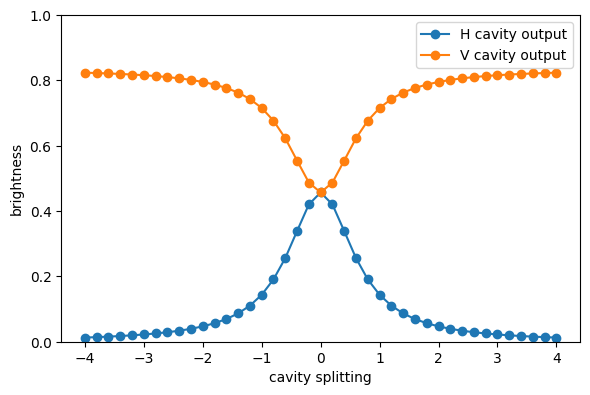

In [74]:
plt.figure(figsize=(6, 4))
plt.plot(detunings, beta_h, 'o-', label='H cavity output')
plt.plot(detunings, beta_v, 'o-', label='V cavity output')
plt.xlabel('cavity_h resonance')
plt.ylabel('brightness')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

With no cavity splitting, the combined brightness from both ports is close to `10/11`. If we detune one cavity mode far away, the remaining resonant branch contributes about half of the total symmetric enhancement, so the combined brightness approaches `5/6`.

In [71]:
source.beta(0, parameters={'cavity_h/resonance': 20}) + \
source.beta(1, parameters={'cavity_h/resonance': 20})

0.83355595234511